In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('girl.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


**Histogram Equalization**

In [36]:

marginal_eq = np.zeros_like(img)
for c in range(3):
    marginal_eq[:, :, c] = cv2.equalizeHist(img[:, :, c])

In [37]:
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

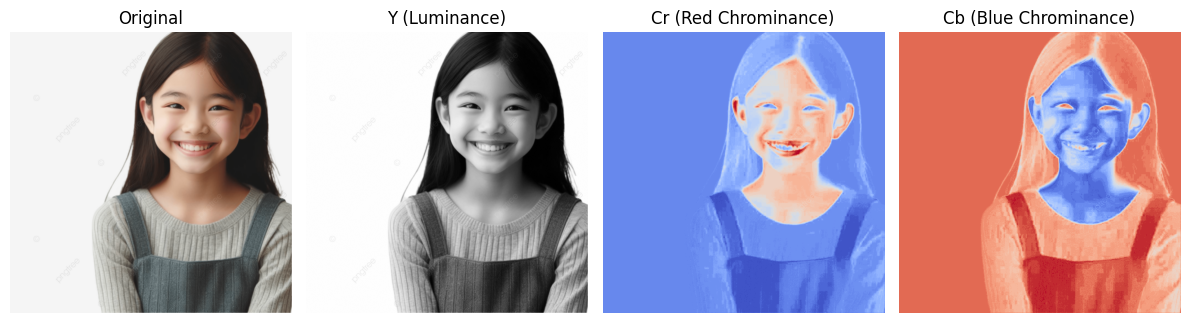

In [38]:


Y, Cr, Cb = img_ycrcb[:, :, 0], img_ycrcb[:, :, 1], img_ycrcb[:, :, 2]


plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(Y, cmap='gray')
plt.title('Y (Luminance)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(Cr, cmap='coolwarm') #false coloring
plt.title('Cr (Red Chrominance)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(Cb, cmap='coolwarm')
plt.title('Cb (Blue Chrominance)')
plt.axis('off')

plt.tight_layout()
plt.show()


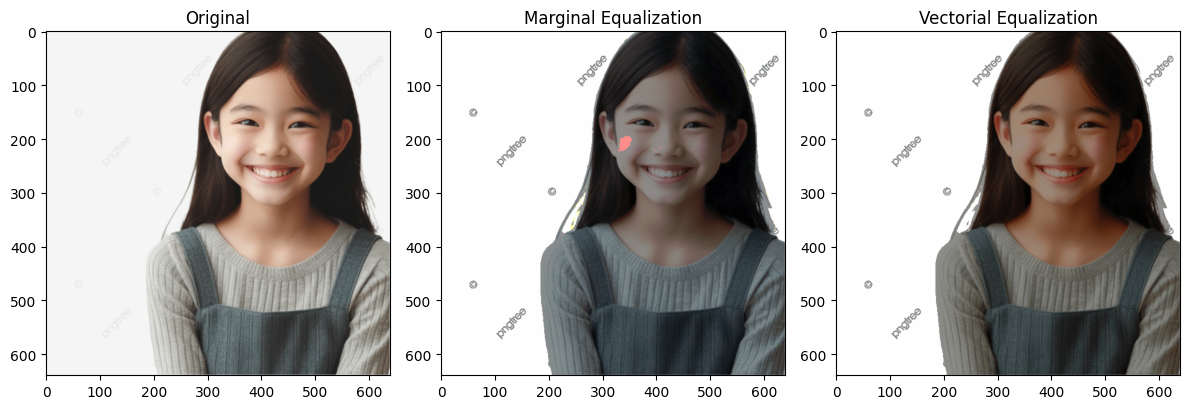

In [39]:







img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])
vectorial_eq = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB)


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(marginal_eq)
plt.title("Marginal Equalization")

plt.subplot(1, 3, 3)
plt.imshow(vectorial_eq)
plt.title("Vectorial Equalization")

plt.tight_layout()
plt.show()


**Edge detection using sobel kernel**

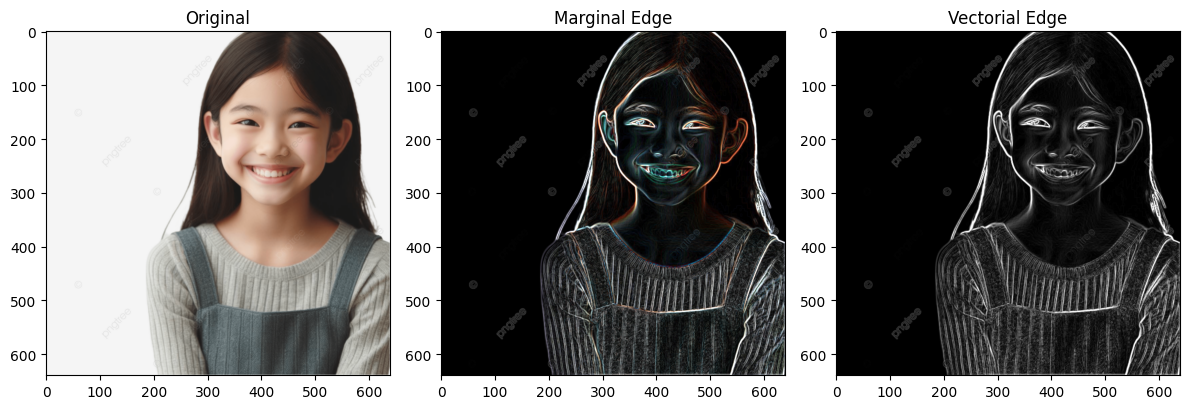

In [40]:

edges_marginal = np.zeros_like(img)
for c in range(3):
    sobelx = cv2.Sobel(img[:, :, c], cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img[:, :, c], cv2.CV_64F, 0, 1, ksize=3)
    edges = np.sqrt(sobelx**2 + sobely**2)
    edges = np.clip(edges, 0, 255).astype(np.uint8)
    edges_marginal[:, :, c] = edges


gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
sobelx_v = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely_v = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
edges_vectorial = np.sqrt(sobelx_v**2 + sobely_v**2)
edges_vectorial = np.clip(edges_vectorial, 0, 255).astype(np.uint8)
edges_vectorial = cv2.cvtColor(edges_vectorial, cv2.COLOR_GRAY2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(edges_marginal)
plt.title("Marginal Edge")

plt.subplot(1, 3, 3)
plt.imshow(edges_vectorial)
plt.title("Vectorial Edge")
plt.tight_layout()
plt.show()


**Median Filter to remove noise**

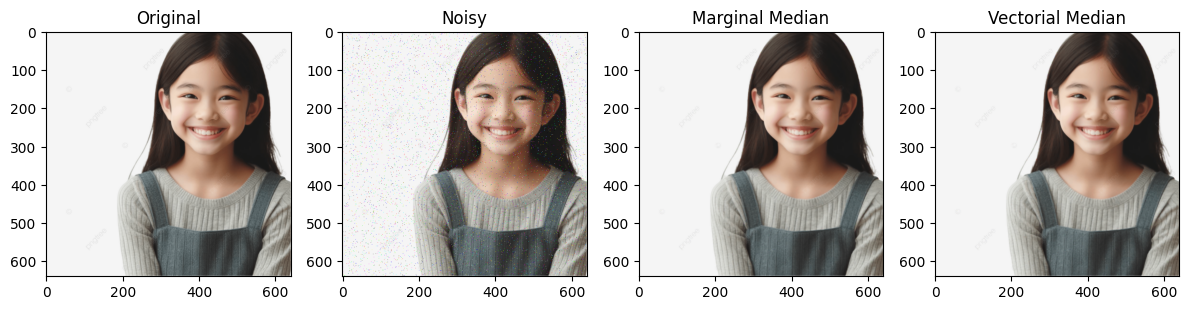

In [41]:

def add_sp_noise(image, amount=0.02):
    noisy = image.copy()
    n_total = int(amount * image.size / 3)
    coords = [np.random.randint(0, i - 1, n_total) for i in image.shape[:2]]
    for c in range(3):
        noisy[coords[0], coords[1], c] = np.random.choice([0, 255], size=n_total)
    return noisy

noisy_img = add_sp_noise(img)

marginal_median = np.zeros_like(img)
for c in range(3):
    marginal_median[:, :, c] = cv2.medianBlur(noisy_img[:, :, c], 3)


vectorial_median = cv2.medianBlur(noisy_img, 3)


plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1, 4, 2)
plt.imshow(noisy_img)
plt.title("Noisy")

plt.subplot(1, 4, 3)
plt.imshow(marginal_median)
plt.title("Marginal Median")

plt.subplot(1, 4, 4)
plt.imshow(vectorial_median)
plt.title("Vectorial Median")
plt.tight_layout()
plt.show()
